## 📦 Setup & Initialization
**Description:** Imports analytical and visualization libraries and loads the primary metadata. Sets up the environment for static plotting (`seaborn`, `matplotlib`) and interactive visualization (`plotly`).

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set publication-quality style for seaborn
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# =====================================================================
# 1. LOAD DATASET
# =====================================================================
# Update this path to match your local directory structure
METADATA_CSV_PATH = r"d:\Resfes\Project\Ser\data\DataFrames\iemocap_metadata.csv"

print("[INFO] Loading IEMOCAP metadata...")
try:
    df = pd.read_csv(METADATA_CSV_PATH)
    # Ensure temporal chronological order
    df = df.sort_values(by=['Session', 'Dialog_ID', 'Turn_Order']).reset_index(drop=True)
    print(f"[SUCCESS] Loaded {len(df)} utterances.")
    display(df.head())
except Exception as e:
    print(f"[ERROR] Could not load dataset. Please check the file path. Details: {e}")

[INFO] Loading IEMOCAP metadata...
[SUCCESS] Loaded 10039 utterances.


,Utterance_ID,Dialog_ID,Session,Turn_Order,Is_Impro,Raw_Emotion,Stage1_Label,Stage2_Label,Valence,Arousal,Dominance,Speaker_Gender,Duration_sec,F0_Mean
0,Ses01F_impro01_F000,Ses01F_impro01,1,0,1,neu,1,-1,2.5,2.5,2.5,F,1.946,105.091
1,Ses01F_impro01_M000,Ses01F_impro01,1,0,1,fru,0,4,2.5,2.0,2.5,M,2.904,96.139
2,Ses01F_impro01_F001,Ses01F_impro01,1,1,1,neu,1,-1,2.5,2.5,2.5,F,1.382,95.311
3,Ses01F_impro01_M001,Ses01F_impro01,1,1,1,fru,0,4,2.5,2.0,2.5,M,3.738,74.590
4,Ses01F_impro01_F002,Ses01F_impro01,1,2,1,neu,1,-1,2.5,2.5,2.5,F,3.130,94.403


## 🔬 PART 1: PURE DATA-DRIVEN EDA

### Step 1.1: Hierarchical Label Distribution
**Description:** Visualizes the dataset's class distribution and hierarchical structure. Maps the native IEMOCAP emotions into 3 macro-sentiments (Positive, Neutral/Other, Negative) to observe class imbalances across different granularities using a Sunburst chart.

In [3]:
# =====================================================================
# HIERARCHICAL MAPPING STRATEGY
# =====================================================================
def assign_macro_sentiment(emotion):
    """Maps raw emotions to macro-sentiments based on IEMOCAP conventions."""
    if emotion in ['hap', 'exc']:
        return 'Positive'
    elif emotion in ['ang', 'sad', 'fea', 'dis', 'fru']:
        return 'Negative'
    else:
        return 'Neutral/Other' # Includes 'neu', 'sur', 'oth', 'xxx'

# Apply mapping
df['Macro_Sentiment'] = df['Raw_Emotion'].apply(assign_macro_sentiment)

# Prepare data for Sunburst Chart
sunburst_data = df.groupby(['Macro_Sentiment', 'Raw_Emotion']).size().reset_index(name='Count')

# Generate Interactive Sunburst Chart using Plotly
fig = px.sunburst(
    sunburst_data, 
    path=['Macro_Sentiment', 'Raw_Emotion'], 
    values='Count',
    title="IEMOCAP Hierarchical Emotion Distribution",
    color='Macro_Sentiment',
    color_discrete_map={
        'Negative': '#EF553B', 
        'Positive': '#00CC96', 
        'Neutral/Other': '#636EFA'
    }
)

fig.update_traces(textinfo="label+percent parent+value")
fig.show()
# NOTE: In a Jupyter Notebook, this will render an interactive HTML chart.

### Step 1.2: Valence-Arousal 2D Space
**Description:** Plots the continuous psychological dimensions (Valence vs. Arousal) to inspect class boundaries and overlap. This helps identify which emotional states share similar arousal and valence profiles, highlighting potential classification bottlenecks.

In [13]:
# =====================================================================
# INTERACTIVE VALENCE-AROUSAL SCATTER PLOT USING PLOTLY
# =====================================================================

# Filter out rows missing Valence or Arousal coordinates to avoid rendering errors
va_df = df.dropna(subset=['Valence', 'Arousal']).copy()

# Generate an interactive 2D scatter plot
# The 'hover_data' parameter controls what fields are displayed when hovering over data points
fig = px.scatter(
    va_df,
    x='Valence',
    y='Arousal',
    color='Raw_Emotion',              # Color-code data points by their raw emotional class
    symbol='Macro_Sentiment',         # Change marker shape based on the macro sentiment group
    title="2D Psychological Space: Valence vs. Arousal (Interactive Exploration)",
    labels={
        'Valence': 'Valence (Negative -> Positive)',
        'Arousal': 'Arousal (Calm -> Excited)',
        'Raw_Emotion': 'Raw Emotion',
        'Macro_Sentiment': 'Macro Sentiment'
    },
    hover_data={
        'Macro_Sentiment': True,      # Show the mapped macro sentiment group in hover tooltip
        'Raw_Emotion': True,          # Show the specific fine-grained emotion class
        'Valence': ':.2f',            # Display valence score with 2 decimal precision
        'Arousal': ':.2f'             # Display arousal score with 2 decimal precision
    },
    opacity=0.6,                      # Set transparency to visually inspect density and overlap
    color_discrete_sequence=px.colors.qualitative.D3
)

# Refine axis boundaries and formatting to match IEMOCAP's 1-5 psychological evaluation scale
fig.update_layout(
    xaxis=dict(range=[0.5, 5.5], dtick=0.5),
    yaxis=dict(range=[0.5, 5.5], dtick=0.5),
    width=900,
    height=700,
    title_font=dict(size=16, family="Arial", color="black"),
    legend_title_text="Emotion Categories"
)

# Adjust marker style size for optimal clarity
fig.update_traces(marker=dict(size=6))

# Render the interactive visualization inside the Jupyter Notebook cell
fig.show()

### Step 1.3: Biometric & Physical Statistics
**Description:** *Note: Requires 'Duration_sec', 'F0_Mean', and 'Speaker_Gender' columns.* Analyzes physical acoustic characteristics to understand biological variances, such as Fundamental Frequency (F0) distribution across genders and emotion classes.

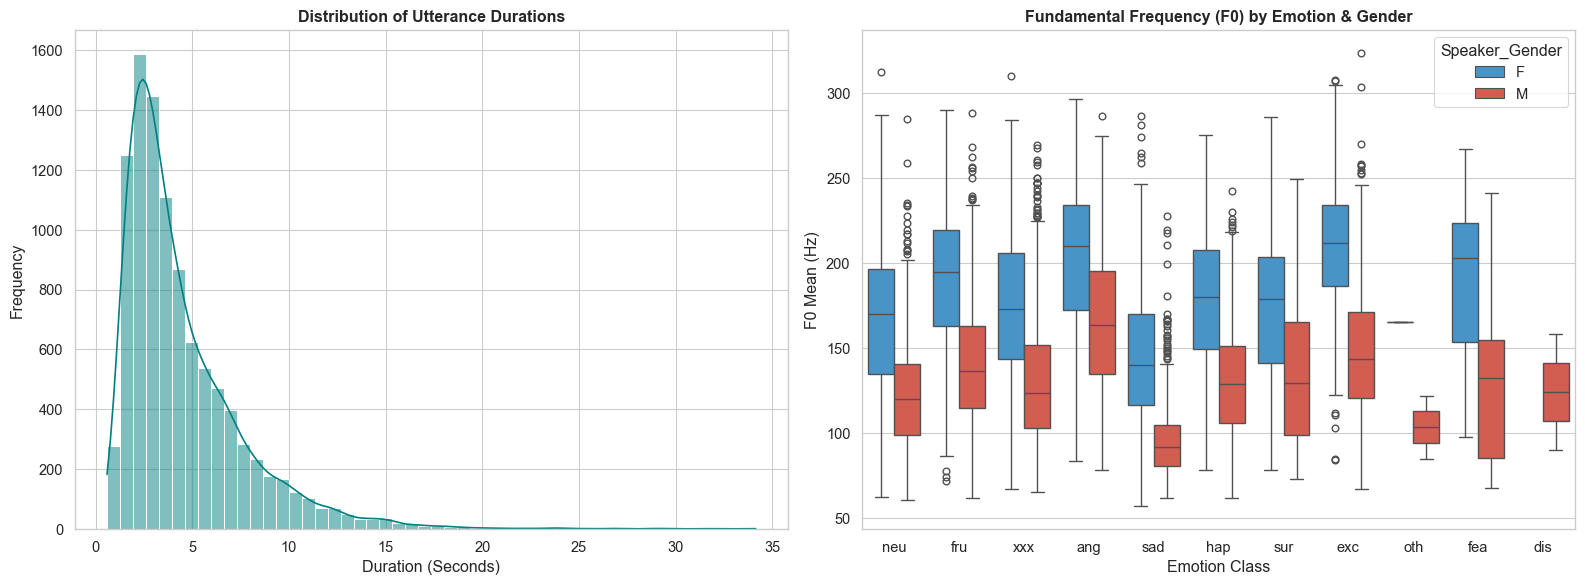

[INFO] Biometric placeholder executed. Ensure acoustic features are extracted to visualize F0/Duration.


In [16]:
# =====================================================================
# BIOMETRIC DISTRIBUTIONS (TEMPLATE)
# =====================================================================


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Utterance Duration Distribution
sns.histplot(df['Duration_sec'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Utterance Durations', fontweight='bold')
axes[0].set_xlabel('Duration (Seconds)')
axes[0].set_ylabel('Frequency')

# 2. F0 (Pitch) Boxplot by Emotion and Gender
sns.boxplot(
    data=df, 
    x='Raw_Emotion', 
    y='F0_Mean', 
    hue='Speaker_Gender', 
    palette=['#3498db', '#e74c3c'], 
    ax=axes[1]
)
axes[1].set_title('Fundamental Frequency (F0) by Emotion & Gender', fontweight='bold')
axes[1].set_xlabel('Emotion Class')
axes[1].set_ylabel('F0 Mean (Hz)')

plt.tight_layout()
plt.show()

print("[INFO] Biometric placeholder executed. Ensure acoustic features are extracted to visualize F0/Duration.")

### Step 1.4: Conversational Dynamics (Markov Chain Heatmap)
**Description:** Calculates the state-transition probability matrix from utterance $t-1$ to utterance $t$ within the same dialogue. Retains unknown ('xxx') labels to preserve temporal sequence integrity. This maps the emotional inertia and transition patterns in natural conversations.

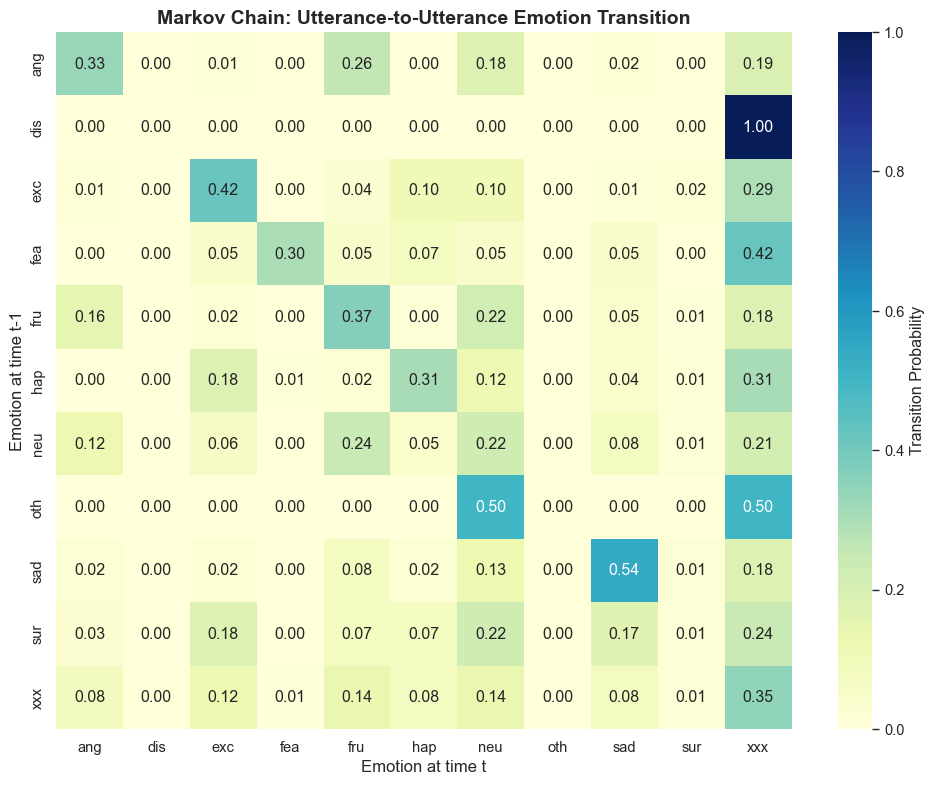

In [17]:
# =====================================================================
# MARKOV CHAIN: EMOTION TRANSITION MATRIX
# =====================================================================
# Create a new column representing the emotion of the NEXT utterance (t+1)
# Grouping by 'Dialog_ID' prevents transitions between separate dialogues.
df['Next_Emotion'] = df.groupby('Dialog_ID')['Raw_Emotion'].shift(-1)

# Drop the last utterances of each dialog (no 'next' state available)
transitions_df = df.dropna(subset=['Next_Emotion'])

# Calculate the cross-tabulation matrix (normalized by row to get probabilities)
transition_matrix = pd.crosstab(
    transitions_df['Raw_Emotion'], 
    transitions_df['Next_Emotion'], 
    normalize='index'
)

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    transition_matrix, 
    annot=True,          # Show probability numbers
    fmt=".2f",           # Format to 2 decimal places
    cmap="YlGnBu",       # Standard analytical color map
    cbar_kws={'label': 'Transition Probability'}
)

plt.title("Markov Chain: Utterance-to-Utterance Emotion Transition", fontsize=14, fontweight='bold')
plt.xlabel("Emotion at time t", fontsize=12)
plt.ylabel("Emotion at time t-1", fontsize=12)
plt.tight_layout()
plt.show()

# Interpretation Focus: 
# High values along the diagonal indicate "Emotional Inertia" (remaining in the same state).